## Import Libraries
we import all necessary libraries for data processing, modeling, and visualization.

In [295]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

## 📥 Step 1: Load Data

In this step, we load the dataset and perform initial inspection.

In [296]:
df = pd.read_csv("data.csv")


## 🔍 Step 2: Exploratory Data Analysis (EDA) |  And Cleaing Data

In this step, we explore the dataset to understand distributions, relationships, and detect potential issues such as missing values and outliers.

In [297]:
print('=' * 50)
print("Start EDA for the dataset.....") 
print('=' * 50)
df.head()

Start EDA for the dataset.....


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [298]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [299]:
# we dont have a miss values in our dataset
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Attrition
No     1233
Yes     237
Name: count, dtype: int64


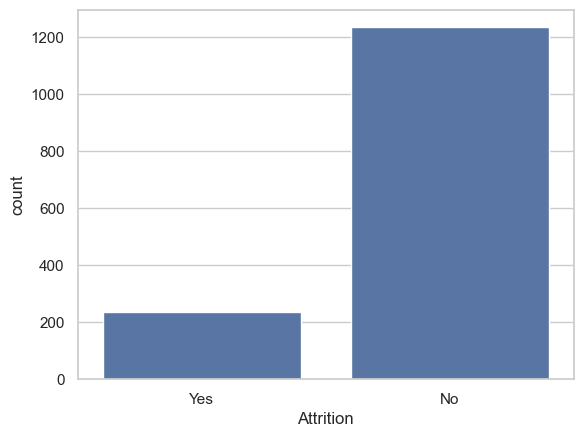

In [301]:
sns.countplot(x='Attrition', data=df)
# Imbalanced Dataset problem
tes = df['Attrition'].value_counts()
print(tes)
# 1233 vs 237

## We Have Problem (Imbalanced Dataset) 
No     1233 
Yes     237

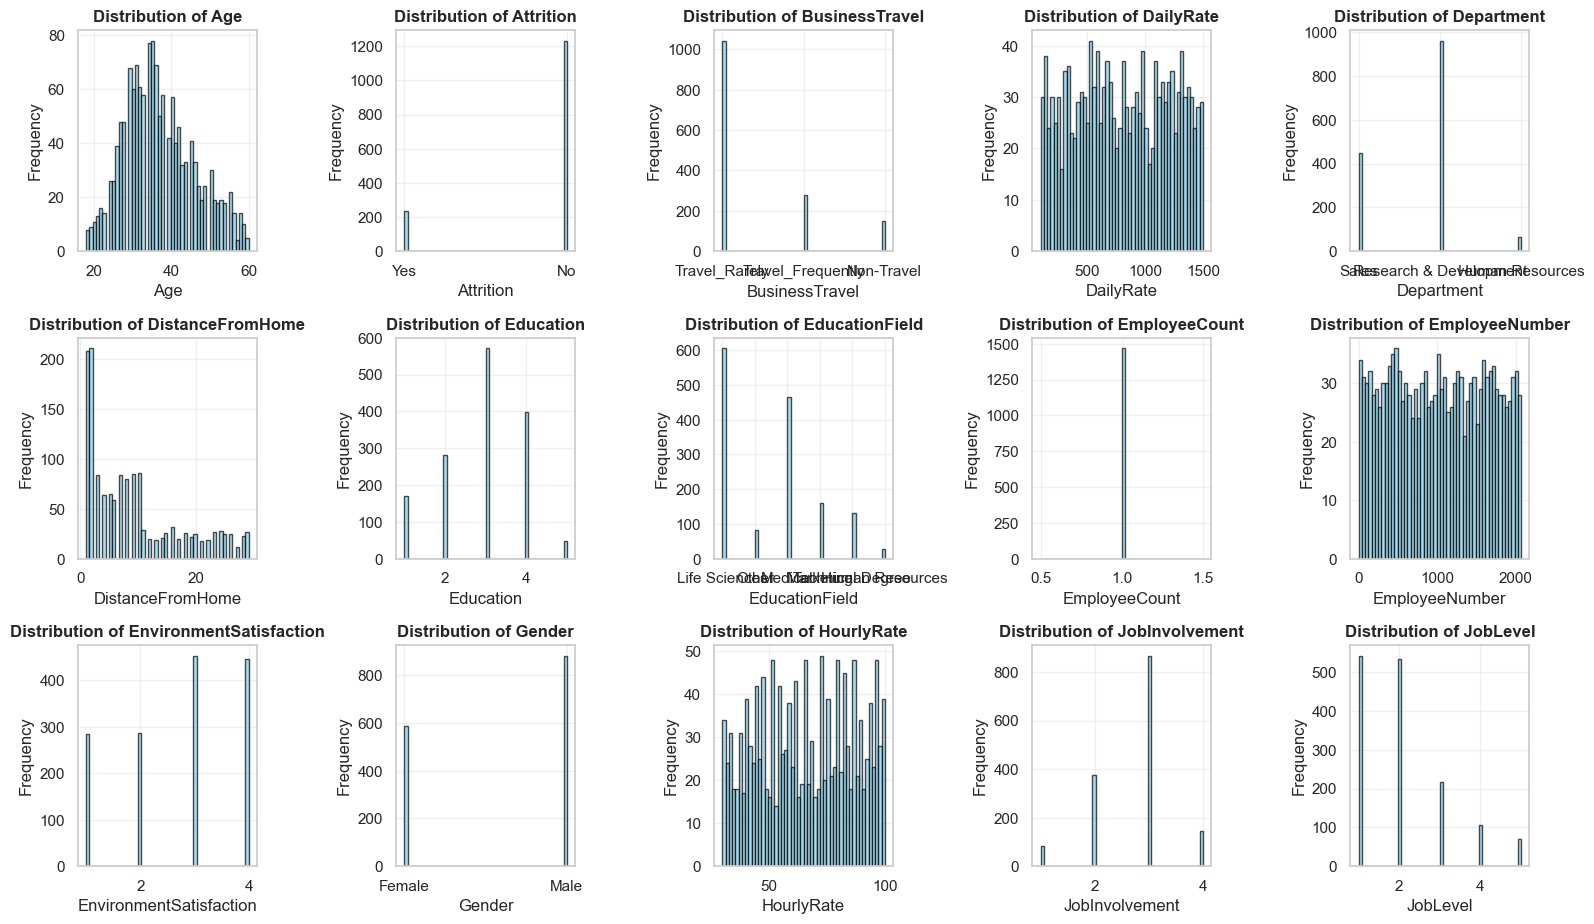

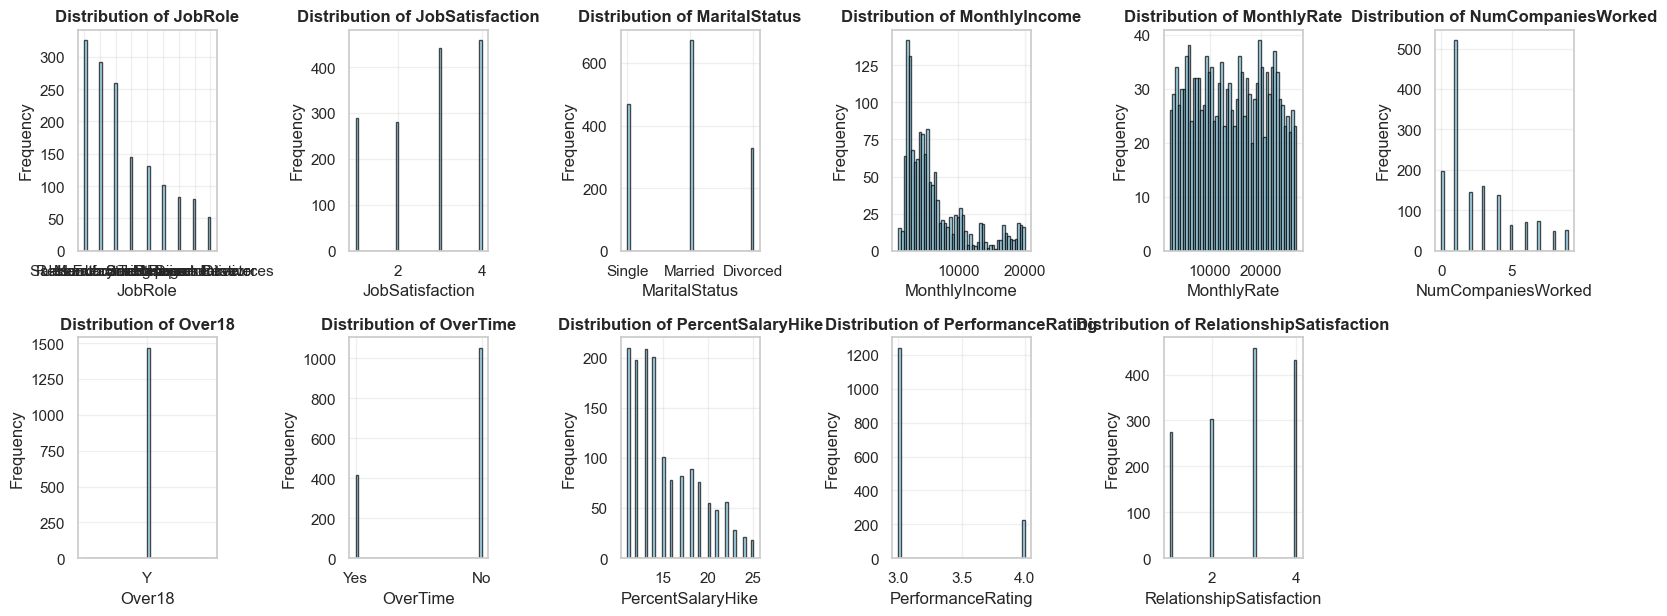

In [302]:
#  Split columns into two groups
cols_part1 = df.columns[:15]   # First 15 columns
cols_part2 = df.columns[15:26] # Next 11 columns

#  Function to plot histograms for a given list of columns
def plot_histograms(df, columns, rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
    axes = axes.ravel()
    
    for i, col in enumerate(columns):
        axes[i].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
    
    # Hide any empty subplots (if total plots < rows*cols)
    for j in range(i + 1, rows * cols):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

#  plot histograms for both parts
plot_histograms(df, cols_part1, rows=4, cols=5)
plot_histograms(df, cols_part2, rows=4, cols=6)

## 🛠️ Step 4: Feature Engineering

In this step, we transform raw data into meaningful features to improve model performance.

Correlation Analysis and Features Engineering...


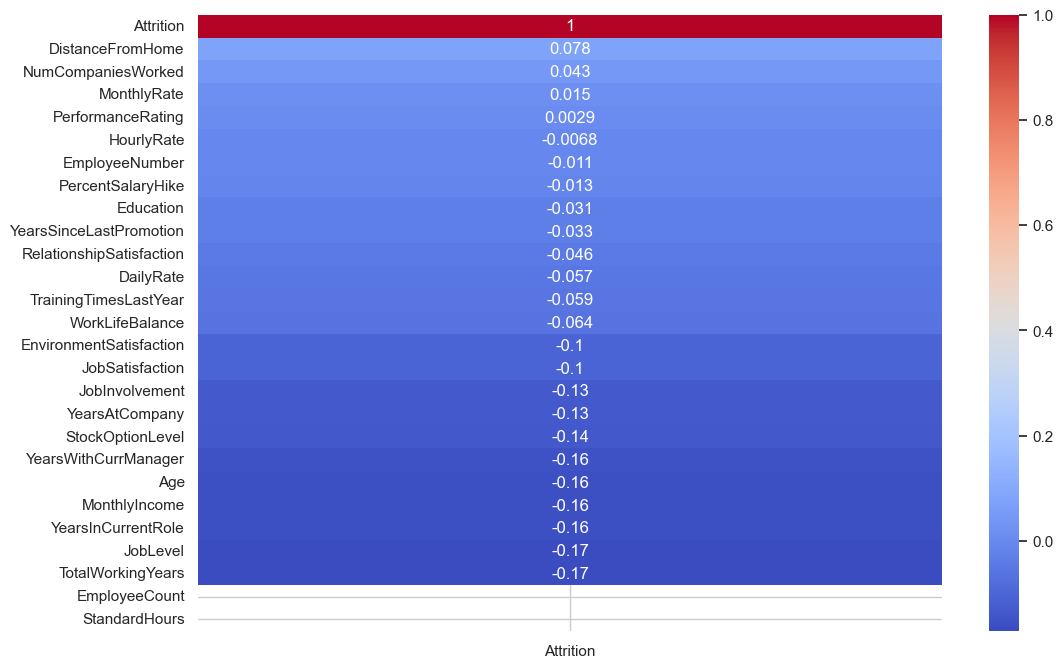

In [ ]:
print('=' * 50)
print("Correlation Analysis and Features Engineering...")
print('=' * 50)

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
corr = df.corr(numeric_only=True)["Attrition"].sort_values(ascending=False)
plt.figure(figsize=(12,8))
sns.heatmap(corr.to_frame(), annot=True, cmap="coolwarm")
plt.show()

print('The correlation values for each feature with respect to Attrition are:')
df.corr()['Attrition'].sort_values()

In [304]:

important_features = [
    "DistanceFromHome",
    "NumCompaniesWorked",
    "Age",
    "JobRole",

    "EnvironmentSatisfaction",
    "MonthlyIncome",
    "OverTime",
    "MaritalStatus",
    "BusinessTravel",
  
    "TotalWorkingYears",
    "JobLevel",
    "YearsInCurrentRole",

    "YearsAtCompany",
    "StockOptionLevel",
    "YearsWithCurrManager", 
    "JobSatisfaction",
    "WorkLifeBalance",
   
]

print("The important features based on correlation analysis are:")
for i in important_features:
    print(i)


df['Stability_Index'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['Income_vs_Department'] = df['MonthlyIncome'] / df.groupby('Department')['MonthlyIncome'].transform('mean')

The important features based on correlation analysis are:
DistanceFromHome
NumCompaniesWorked
Age
JobRole
EnvironmentSatisfaction
MonthlyIncome
OverTime
MaritalStatus
BusinessTravel
TotalWorkingYears
JobLevel
YearsInCurrentRole
YearsAtCompany
StockOptionLevel
YearsWithCurrManager
JobSatisfaction
WorkLifeBalance


### 🗑️ Feature Selection (Dropping Irrelevant Features)

In this step, we removed a set of features that were considered irrelevant, redundant, or potentially harmful to the model's performance.

---

### 🎯 Why were these features dropped?

Several reasons guided this decision:

#### 🔹 1. Irrelevant Identifiers
- `EmployeeNumber`, `EmployeeCount`
These columns are unique identifiers or constant values and do not contribute to predicting attrition.

---

#### 🔹 2. Low-Impact or Noisy Features
- `DailyRate`, `HourlyRate`, `MonthlyRate`
These features may introduce noise without providing strong predictive signals.

---

#### 🔹 3. Redundant or Weakly Informative Features
- `Education`, `EducationField`, `Department`
These may overlap with other more informative features or have low correlation with the target.

---

#### 🔹 4. Low Variance Features
- `StandardHours`, `Over18`
These columns contain little to no variation and therefore do not help the model learn meaningful patterns.

---

#### 🔹 5. Potentially Less Relevant Behavioral Features
- `WorkLifeBalance`, `RelationshipSatisfaction`, `JobInvolvement`, `TrainingTimesLastYear`
These features were tested but showed limited impact on model performance.

---

### 📌 Impact

Removing these features:
- Reduces model complexity  
- Helps prevent overfitting  
- Improves training efficiency  

---

> ⚠️ Note: Feature removal decisions were based on exploratory analysis and model performance observations.

In [305]:
drop_cols = [
    "BusinessTravel",
    "DailyRate",
    "Department",
    "Education",
    "EducationField",
    "EmployeeCount",
    "EmployeeNumber",
    "Gender",
    "HourlyRate",
    "JobInvolvement",
    "TrainingTimesLastYear",
    "PercentSalaryHike",
    "Over18",
    "PerformanceRating",
    "YearsSinceLastPromotion",
    "WorkLifeBalance",
    "RelationshipSatisfaction",
    "StandardHours",
    "MonthlyRate"
]

df = df.drop(columns=drop_cols)
print("Drop Successfully")

Drop Successfully


### 🔢 Encoding Boolean Features to Numeric

Convert boolean features (True/False) into numeric format (1/0) for model compatibility.

In [306]:
print("Incoding the boolean features to numeric...")
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

Incoding the boolean features to numeric...


### 🔤 Encoding Categorical Variables

The dataset contains categorical features stored as object data types, which cannot be directly used by machine learning models.

To address this, we applied **One-Hot Encoding** using `pd.get_dummies()`:

- First, categorical columns were identified using their data type (`object`)
- Then, each category was converted into a separate binary column (0/1)

---

### 🎯 Why One-Hot Encoding?

- The categorical variables in this dataset are **nominal** (no inherent order)
- One-Hot Encoding prevents the model from assuming any ordinal relationship between categories
- It is compatible with most machine learning models, including linear and tree-based models

---

### ⚙️ Implementation Details

- Encoding was applied to all categorical columns at once
- We used `drop_first=True` to:
  - Reduce redundancy
  - Avoid multicollinearity in linear models


> ⚠️ Note: Encoding should ideally be applied after splitting the data or within a pipeline to avoid data leakage.

In [307]:
categorical_cols = df.select_dtypes(include="object").columns

In [308]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## ✂️ Step 5: Split Data

In this step, we split the dataset into training and testing sets to evaluate model performance properly.

In [309]:
print("Splitting the dataset into train and test sets...")
print("The shape of the dataset is:", df.shape)
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
print("The shape of the features (X) is:", X.shape)
print("The shape of the target (y) is:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)


Splitting the dataset into train and test sets...
The shape of the dataset is: (1470, 26)
The shape of the features (X) is: (1470, 25)
The shape of the target (y) is: (1470,)


### ⚖️ Handling Class Imbalance

The dataset is highly imbalanced, where the majority class (**Attrition = 0**) dominates the minority class (**Attrition = 1**).  
This imbalance can negatively affect the model’s ability to correctly predict the minority class.

To address this issue, multiple resampling techniques were experimented with:

#### 🔹 1. Random Upsampling
A simple approach where the minority class is duplicated to match the majority class size.  
While effective, it may lead to overfitting due to repeated samples.

#### 🔹 2. SMOTE (Synthetic Minority Oversampling Technique)
SMOTE generates synthetic samples of the minority class, improving generalization compared to simple duplication.

#### 🔹 3. SMOTE + Tomek Links (Final Choice ✅)
The best performance was achieved using **SMOTE combined with Tomek Links**:
- **SMOTE** creates synthetic minority samples  
- **Tomek Links** removes overlapping/noisy samples between classes  

This combination helps:
- Improve class separation  
- Reduce noise  
- Enhance model generalization  

---

### 🎯 Final Decision

Based on experimental results, **SMOTE + Tomek Links** provided the best balance between precision and recall, resulting in the highest **F1-score**.

---

### 📌 Impact

Using SMOTE + Tomek Links significantly improved the model’s ability to correctly identify the minority class, while maintaining good overall performance.

---

> ⚠️ Note: Resampling techniques are applied only on the training data using a pipeline to avoid data leakage.

## 🤖 Step 6: Modeling

In this step, we train multiple machine learning models on the prepared dataset and evaluate their performance.

The goal is to identify the best-performing model based on appropriate evaluation metrics such as F1-score, especially due to class imbalance in the dataset.

Models used:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost
- VotingClassifier

We also apply hyperparameter tuning using cross-validation to improve model performance and reduce overfitting.

In [311]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
import xgboost


# تأكد من تغيير هذه الأسماء من Regressor إلى Classifier
advanced_models = {
    'XGBClassifier': xgboost.XGBClassifier(
        scale_pos_weight= (255/39),
        use_label_encoder=False,
        
    ),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    
    'Logistic Regression': LogisticRegression(solver='saga', max_iter=1000, random_state=42),
    
    'Voting Ensemble': VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(random_state=42)),
            ('gb', GradientBoostingClassifier(random_state=42)),
            ('lr', LogisticRegression(solver='saga', max_iter=1000, random_state=42))
        ],
        voting='soft'
    )
}

### ⚙️ Hyperparameter Tuning

In this step, we optimize model performance by tuning hyperparameters using RandomizedSearchCV.  
This helps in finding the best combination of parameters that improves the model’s generalization and reduces overfitting.

In [313]:
# شبكة البارامترات لنماذج التصنيف (Classification)
param_grids = {
    'XGBClassifier': {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, 5, 10], # مهم جداً لحالتك (البيانات غير المتوازنة)
    'gamma': [0, 0.1, 0.2] # للتحكم في الـ Overfitting
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy'], # مخصصة للتصنيف
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', None] # مهم جداً بسبب الـ Imbalance في بياناتك
    },
    
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5],
        'subsample': [0.8, 0.9, 1.0],
        'loss': ['log_loss', 'exponential'] # مخصصة للتصنيف (تحديث من deviance لـ log_loss)
    },
    
    'Logistic Regression': { # بدلاً من Ridge Regression
        'C': [0.001, 0.01, 0.1, 1.0, 10.0], # قوة الانتظام (Inverse of alpha)
        'penalty': ['l1', 'l2', 'elasticnet'], # أنواع العقوبات
        'solver': ['saga'], # يدعم جميع أنواع الـ penalty
        'max_iter': [1000]
    },
    
    'Voting Ensemble': {
        # نستخدم أسماء الموديلات المعرفة داخل الـ VotingClassifier
        'lr__C': [0.1, 1.0, 10.0],
        'rf__n_estimators': [100, 200],
        'rf__criterion': ['gini', 'entropy'],
        'gb__n_estimators': [100],
        'gb__learning_rate': [0.05, 0.1]
    }
}

In [314]:


# ===========================
# 🎯 Scoring
# ===========================
scoring = 'f1_weighted'

print("🚀 STARTING FULL TRAINING PIPELINE...")

tuned_models = {}
optimization_results = {}

model_list = ['XGBClassifier','Random Forest', 'Gradient Boosting', 'Logistic Regression']

for model_name in model_list:
    print(f"\n🔧 Tuning {model_name}...")

    model = advanced_models[model_name]

    # ===========================
    # 🧠 Pipeline (SMOTE داخل CV)
    # ===========================
    pipeline = ImbPipeline([
        ('smote', SMOTETomek(random_state=42)),
        ('model', model)
    ])

    # تعديل أسماء الـ params لتناسب pipeline
    param_dist = {
        f"model__{k}": v for k, v in param_grids[model_name].items()
    }

    with mlflow.start_run(run_name=f"{model_name}_tuned"):

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_dist,
            n_iter=20,
            cv=5,
            scoring=scoring,
            n_jobs=-1,
            random_state=42,
            verbose=0
        )

        # ===========================
        # Training
        # ===========================
        search.fit(X_train, y_train)

        best_model = search.best_estimator_

        # ===========================
        # 📊 Predictions
        # ===========================
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_f1 = f1_score(y_train, y_train_pred, average='weighted')
        test_f1 = f1_score(y_test, y_test_pred, average='weighted')
        test_acc = accuracy_score(y_test, y_test_pred)

        # AUC (لو متاح)
        if hasattr(best_model, "predict_proba"):
            y_proba = best_model.predict_proba(X_test)[:, 1]
            test_auc = roc_auc_score(y_test, y_proba)
        else:
            test_auc = np.nan

        overfit_gap = train_f1 - test_f1

        # ===========================
        #  Store results
        # ===========================
        tuned_models[model_name] = best_model

        optimization_results[model_name] = {
            'val_f1': test_f1,
            'val_accuracy': test_acc,
            'val_auc': test_auc,
            'cv_f1_mean': search.best_score_,
            'overfitting_gap': overfit_gap
        }

        # ===========================
        #  MLflow Logging
        # ===========================
        mlflow.log_params(search.best_params_)
        mlflow.log_metric("test_f1", test_f1)
        mlflow.log_metric("test_accuracy", test_acc)
        mlflow.log_metric("test_auc", test_auc)
        mlflow.log_metric("overfitting_gap", overfit_gap)

        mlflow.sklearn.log_model(best_model, model_name.replace(" ", "_"))

        print(f"✅ {model_name}")
        print(f"   F1: {test_f1:.4f} | Acc: {test_acc:.4f} | AUC: {test_auc:.4f}")
        print(f"   Overfit Gap: {overfit_gap:.4f}")
        print(classification_report(y_test, y_test_pred))



🚀 STARTING FULL TRAINING PIPELINE...

🔧 Tuning XGBClassifier...


C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [18:26:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/04/20 18:26:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 18:26:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ XGBClassifier
   F1: 0.8300 | Acc: 0.8462 | AUC: 0.7411
   Overfit Gap: 0.1531
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       190
           1       0.42      0.26      0.32        31

    accuracy                           0.85       221
   macro avg       0.65      0.60      0.62       221
weighted avg       0.82      0.85      0.83       221


🔧 Tuning Random Forest...


C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` s

✅ Random Forest
   F1: 0.8300 | Acc: 0.8416 | AUC: 0.7168
   Overfit Gap: 0.1547
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       190
           1       0.41      0.29      0.34        31

    accuracy                           0.84       221
   macro avg       0.65      0.61      0.62       221
weighted avg       0.82      0.84      0.83       221


🔧 Tuning Gradient Boosting...


2026/04/20 18:28:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 18:28:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Gradient Boosting
   F1: 0.8296 | Acc: 0.8371 | AUC: 0.7260
   Overfit Gap: 0.1269
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       190
           1       0.40      0.32      0.36        31

    accuracy                           0.84       221
   macro avg       0.65      0.62      0.63       221
weighted avg       0.82      0.84      0.83       221


🔧 Tuning Logistic Regression...


C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1160: Us

✅ Logistic Regression
   F1: 0.7794 | Acc: 0.7873 | AUC: 0.5859
   Overfit Gap: -0.0097
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       190
           1       0.19      0.16      0.18        31

    accuracy                           0.79       221
   macro avg       0.53      0.53      0.53       221
weighted avg       0.77      0.79      0.78       221



## 📊 Visualization of Model Output

we visualize the model performance to better understand its behavior and evaluation results.

We focus on:
- Model comparison (F1-score)
- Overfitting analysis
- Confusion Matrix
- ROC Curve (if applicable)


📊 Model Comparison:
                 Model    val_f1  val_accuracy   val_auc  cv_f1_mean  \
0        XGBClassifier  0.830047      0.846154  0.741087    0.846852   
1        Random Forest  0.830014      0.841629  0.716808    0.851450   
2    Gradient Boosting  0.829644      0.837104  0.725976    0.842709   
3  Logistic Regression  0.779384      0.787330  0.585908    0.765318   

   overfitting_gap  
0         0.153090  
1         0.154667  
2         0.126899  
3        -0.009733  


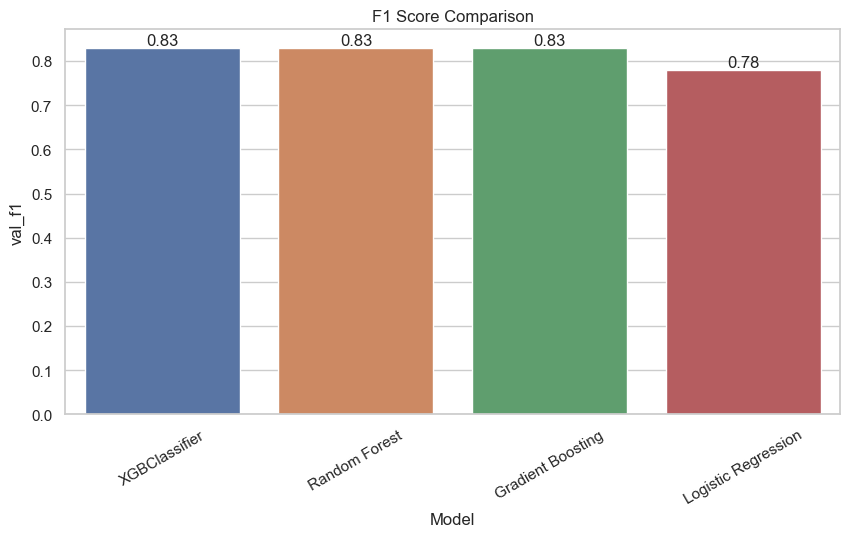

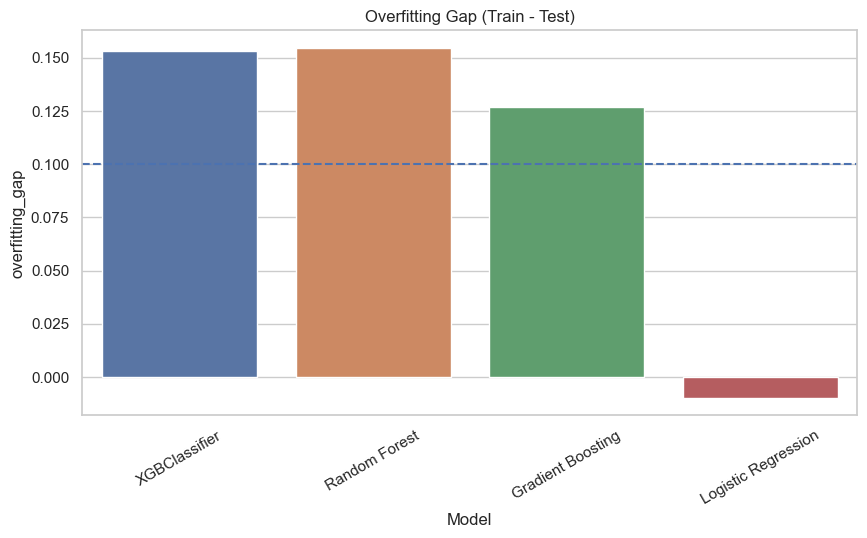


🏆 BEST MODEL: XGBClassifier


In [315]:

# ===========================
# 📊 Analysis DataFrame
# ===========================
metrics_df = pd.DataFrame(optimization_results).T.reset_index()
metrics_df = metrics_df.rename(columns={'index': 'Model'})
metrics_df = metrics_df.sort_values(by='val_f1', ascending=False)

print("\n📊 Model Comparison:")
print(metrics_df)

# ===========================
# 📈 Visualization
# ===========================
sns.set_theme(style="whitegrid")

# F1 Score
plt.figure(figsize=(10,5))
ax = sns.barplot(data=metrics_df, x='Model', y='val_f1', hue='Model', legend=False)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("F1 Score Comparison")
plt.xticks(rotation=30)
plt.show()

# Overfitting
plt.figure(figsize=(10,5))
sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', hue='Model', legend=False)

plt.axhline(0.1, linestyle='--')
plt.title("Overfitting Gap (Train - Test)")
plt.xticks(rotation=30)
plt.show()

# ===========================
# 🏆 Best Model
# ===========================
best_model_name = metrics_df.iloc[0]['Model']
print(f"\n🏆 BEST MODEL: {best_model_name}")

## 🏁 Conclusion

In this project, we aimed to predict employee attrition using machine learning techniques while addressing key challenges such as class imbalance and feature relevance.

---

### 🎯 Key Findings

- The dataset was significantly imbalanced, which required applying resampling techniques.
- Among the tested methods, **SMOTE + Tomek Links** provided the best balance between precision and recall.
- Feature engineering and proper encoding improved the model’s ability to learn meaningful patterns.
- Removing irrelevant and low-impact features helped reduce noise and improve model performance.

---

### 🤖 Model Performance

- Multiple models were trained and evaluated using **F1-score** as the primary metric due to class imbalance.
- The best-performing model achieved strong performance in detecting the minority class while maintaining overall accuracy.
- Hyperparameter tuning further improved model generalization and reduced overfitting.

---

### ⚖️ Trade-offs

- While SMOTE + Tomek improved performance, it increased computational cost.
- Some feature removal decisions may lead to loss of potentially useful information.
- Model performance is still dependent on the quality and size of the dataset.

---

### 🚀 Future Work

- Apply advanced tuning techniques (e.g., Optuna or Bayesian Optimization)
- Explore more sophisticated feature engineering techniques
- Test additional models such as LightGBM or CatBoost
- Deploy the model using a web application (e.g., Streamlit)

---

### 📌 Final Remark

This project demonstrates the importance of handling imbalanced data, thoughtful feature engineering, and systematic model evaluation in building reliable machine learning solutions.
> 💡 The focus was not only on achieving high accuracy, but on building a model that performs well on the minority class, which is critical in real-world decision-making.